In [1]:
import pandas as pd
from dotenv import load_dotenv
import os 

In [2]:
import sys
sys.path.append("..")

In [3]:
from utils.get_market_data import get_candles

In [4]:
from datetime import datetime, timedelta, timezone
now = datetime.now()
from_ = now - timedelta(days=90)
sber_price = get_candles("SBER", from_, now, interval=1)
sber_price.head()

Number of deleted duplicates: 0


,open,close,high,low,value,volume,end
timestamp,,,,,,,
2026-02-21 11:54:00,313.56,313.57,313.57,313.55,50483.64,161,2026-02-21 11:54:59
2026-02-21 11:55:00,313.57,313.56,313.57,313.56,62712.17,200,2026-02-21 11:55:59
2026-02-21 11:56:00,313.57,313.57,313.57,313.55,112254.0,358,2026-02-21 11:56:59
2026-02-21 11:57:00,313.55,313.55,313.57,313.55,58949.9,188,2026-02-21 11:57:59
2026-02-21 11:58:00,313.57,313.57,313.57,313.55,45466.87,145,2026-02-21 11:58:59


In [5]:
load_dotenv()
db_url = os.getenv("DB_URL")

In [6]:
import psycopg2

conn = psycopg2.connect(db_url)
cur = conn.cursor()

ticker = "SR320CD6A"
strike = 320
expiry_date = datetime(2026, 4, 1, 19, tzinfo=timezone.utc)

cur.execute("""
SELECT timestamp, bids, asks FROM orderbooks
WHERE ticker = %s
""", (ticker,))

rows = cur.fetchall()

In [55]:
df = pd.DataFrame(rows, columns=['timestamp', 'bids', 'asks'])
df.head(1)

,timestamp,bids,asks
0,2026-03-23 16:00:48+00:00,"[{'price': 2.2, 'quantity': 1}, {'price': 1.89...","[{'price': 2.99, 'quantity': 447}, {'price': 3..."


In [56]:
df['best_bid'] = df['bids'].apply(lambda x: x[0]['price'] if x else None)
df['best_ask'] = df['asks'].apply(lambda x: x[0]['price'] if x else None)

df['mid'] = ((df['best_ask'] + df['best_bid']) / 2)#.fillna(df['best_ask']).fillna(df['best_bid'])
df = df[['timestamp', 'best_bid', 'best_ask', 'mid']]

In [57]:
df['time_to_expiry'] = df['timestamp'].apply(lambda x: (expiry_date - x).total_seconds()/31536000)
df.head(1)

,timestamp,best_bid,best_ask,mid,time_to_expiry
0,2026-03-23 16:00:48+00:00,2.2,2.99,2.595,0.024998


In [58]:
sber_price_df = sber_price[['close']]
sber_price_df.head(5)

,close
timestamp,
2026-02-21 11:54:00,313.57
2026-02-21 11:55:00,313.56
2026-02-21 11:56:00,313.57
2026-02-21 11:57:00,313.55
2026-02-21 11:58:00,313.57


In [59]:
sber_price_df['merge_time'] = sber_price_df.index
sber_price_df['merge_time'] = sber_price_df['merge_time'].dt.tz_localize('UTC')
sber_price_df = sber_price_df.sort_values('merge_time')
df = df.sort_values('timestamp')


merged_df = pd.merge_asof(
    df,
    sber_price_df,
    left_on = "timestamp",
    right_on = "merge_time"
)

merged_df.dropna(inplace=True)
merged_df.head()

,timestamp,best_bid,best_ask,mid,time_to_expiry,close,merge_time
0,2026-03-23 15:50:01+00:00,2.20,2.99,2.595,0.025019,317.09,2026-03-23 15:50:00+00:00
1,2026-03-23 15:50:01+00:00,2.20,2.99,2.595,0.025019,317.09,2026-03-23 15:50:00+00:00
2,2026-03-23 15:50:01+00:00,2.20,2.99,2.595,0.025019,317.09,2026-03-23 15:50:00+00:00
3,2026-03-23 16:00:48+00:00,2.20,2.99,2.595,0.024998,317.1,2026-03-23 16:00:00+00:00
4,2026-03-23 16:05:42+00:00,1.89,2.99,2.440,0.024989,317.01,2026-03-23 16:05:00+00:00


In [60]:
from utils.iv_solver import iv_newton

def exception_iv(row):
    try:
        return iv_newton(
            row.close, 
            strike, 
            0.13, 
            row.time_to_expiry, 
            row.mid, 
            "CALL",
            0.0001 , 
            100
        )
    except ValueError as e:
        print(e)
        return None
        

merged_df['IV'] = merged_df.apply(lambda row: exception_iv(row), axis=1)
merged_df.head(1)

,timestamp,best_bid,best_ask,mid,time_to_expiry,close,merge_time,IV
0,2026-03-23 15:50:01+00:00,2.2,2.99,2.595,0.025019,317.09,2026-03-23 15:50:00+00:00,0.171922


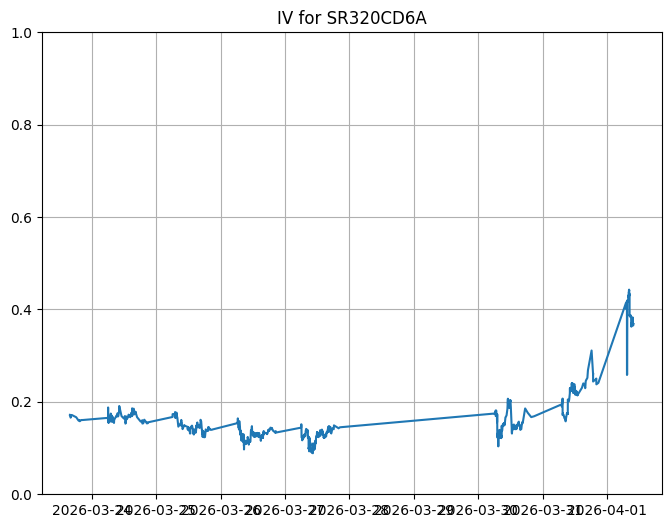

In [63]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(8,6))

plt.plot(merged_df['timestamp'], merged_df['IV'])
plt.title(f"IV for {ticker}")
plt.ylim(0, 1)
plt.grid()

In [64]:
merged_df.sort_values(by='IV', ascending=False).

,timestamp,best_bid,best_ask,mid,time_to_expiry,close,merge_time,IV
4000,2026-04-01 08:13:48+00:00,0.01,0.59,0.3,0.001229,314.24,2026-04-01 08:13:00+00:00,0.442887
3995,2026-04-01 08:11:56+00:00,0.01,0.59,0.3,0.001233,314.24,2026-04-01 08:11:00+00:00,0.442277
3994,2026-04-01 08:11:55+00:00,0.01,0.59,0.3,0.001233,314.24,2026-04-01 08:11:00+00:00,0.442277
3992,2026-04-01 08:11:33+00:00,0.01,0.59,0.3,0.001234,314.24,2026-04-01 08:11:00+00:00,0.442124
3993,2026-04-01 08:11:35+00:00,0.01,0.59,0.3,0.001234,314.24,2026-04-01 08:11:00+00:00,0.442124
...,...,...,...,...,...,...,...,...
1958,2026-03-27 10:20:30+00:00,0.30,0.50,0.4,0.014687,316.55,2026-03-27 10:20:00+00:00,0.089702
1957,2026-03-27 10:20:25+00:00,0.30,0.50,0.4,0.014687,316.55,2026-03-27 10:20:00+00:00,0.089702
1956,2026-03-27 10:20:04+00:00,0.30,0.50,0.4,0.014688,316.55,2026-03-27 10:20:00+00:00,0.089699
1968,2026-03-27 10:22:23+00:00,0.30,0.50,0.4,0.014683,316.6,2026-03-27 10:22:00+00:00,0.088770
